In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%%capture
!pip install rdkit

In [3]:
%%capture
!pip install deepchem

In [4]:
%%capture
!pip install torch-geometric

In [5]:
import pandas as pd
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw, rdmolops
import torch
import torch_geometric
from torch_geometric.data import Dataset
import numpy as np
from tqdm import tqdm
import os
import deepchem as dc

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


In [6]:
# Importo il mio dataset
from torch_geometric.datasets import MoleculeNet
dataset = MoleculeNet(root="data/HIV", name="HIV")

Processing...
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:266: UserWarning: Skipping molecule 'O=C1O[Al]23(OC1=O)(OC(=O)C(=O)O2)OC(=O)C(=O)O3' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:266: UserWarning: Skipping molecule 'Cc1ccc([B-2]2(c3ccc(C)cc3)=NCCO2)cc1' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:266: UserWarning: Skipping molecule 'Oc1ccc(C2Oc3cc(O)cc4c3C(=[O+][AlH3-3]35([O+]=C6c7c(cc(O)cc7[OH+]3)OC(c3ccc(O)cc3O)C6O)([O+]=C3c6c(cc(O)cc6[OH+]5)OC(c5ccc(O)cc5O)C3O)[OH+]4)C2O)c(O)c1' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/dataset.py:266: UserWarning: Skipping molecule 'CC1=C2[OH+][AlH3-3]34([O+]=C2C=CN1C)([O+]=C1C=CN(C)C(C)=C1[OH+]3)[O+]=C1C=CN(C)C(C)=C1[OH+]4' since it resulted in zero atoms
  self.process()
/usr/local/lib/python3

In [7]:
from torch_geometric.utils import from_smiles

smile_graph = from_smiles(dataset[0].smiles)
smile_graph

Data(x=[19, 9], edge_index=[2, 40], edge_attr=[40, 3], smiles='CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)=[O+]2')

Dataset:
https://apxml.com/courses/getting-started-with-pytorch/chapter-5-efficient-data-handling/working-with-dataset

# Dataset exploration


In [8]:
from numpy import random

In [9]:
LEN = dataset.__len__()
print('Il dataset possiede', LEN, 'elementi')


Il dataset possiede 41120 elementi


In [10]:

ran = random.randint(LEN)
dataset.__getitem__(ran)

Data(x=[15, 9], edge_index=[2, 30], edge_attr=[30, 3], smiles='CC(=NNC(=S)N(C)C)c1cccnn1', y=[1, 1])

In [11]:
def pick_rand(dataset, label):
    dataset_shuff = dataset.shuffle()
    for d in dataset_shuff:
      if len(d.smiles) > 30:
        if d.y == label:
            return d



# nota: se esce una molecola tipo CCOC(=O)C(C)=C(O)C(=O)OCC.[NaH], il
# significato è che Nah e l'altra sono due molecole distinte nella
# stessa miscela.

example_pos = pick_rand(dataset, 1)

example_neg = pick_rand(dataset, 0)

print('Smiles d\'esempio di classe 0:', example_pos.smiles)
print('Smiles d\'esempio di classe 1:', example_neg.smiles)

Smiles d'esempio di classe 0: Cc1cnc2sn(-c3ccc([N+](=O)[O-])cc3)c(=O)c2c1
Smiles d'esempio di classe 1: CCOC(=O)c1ccc(CSc2ccc(N)cc2)c([N+](=O)[O-])c1


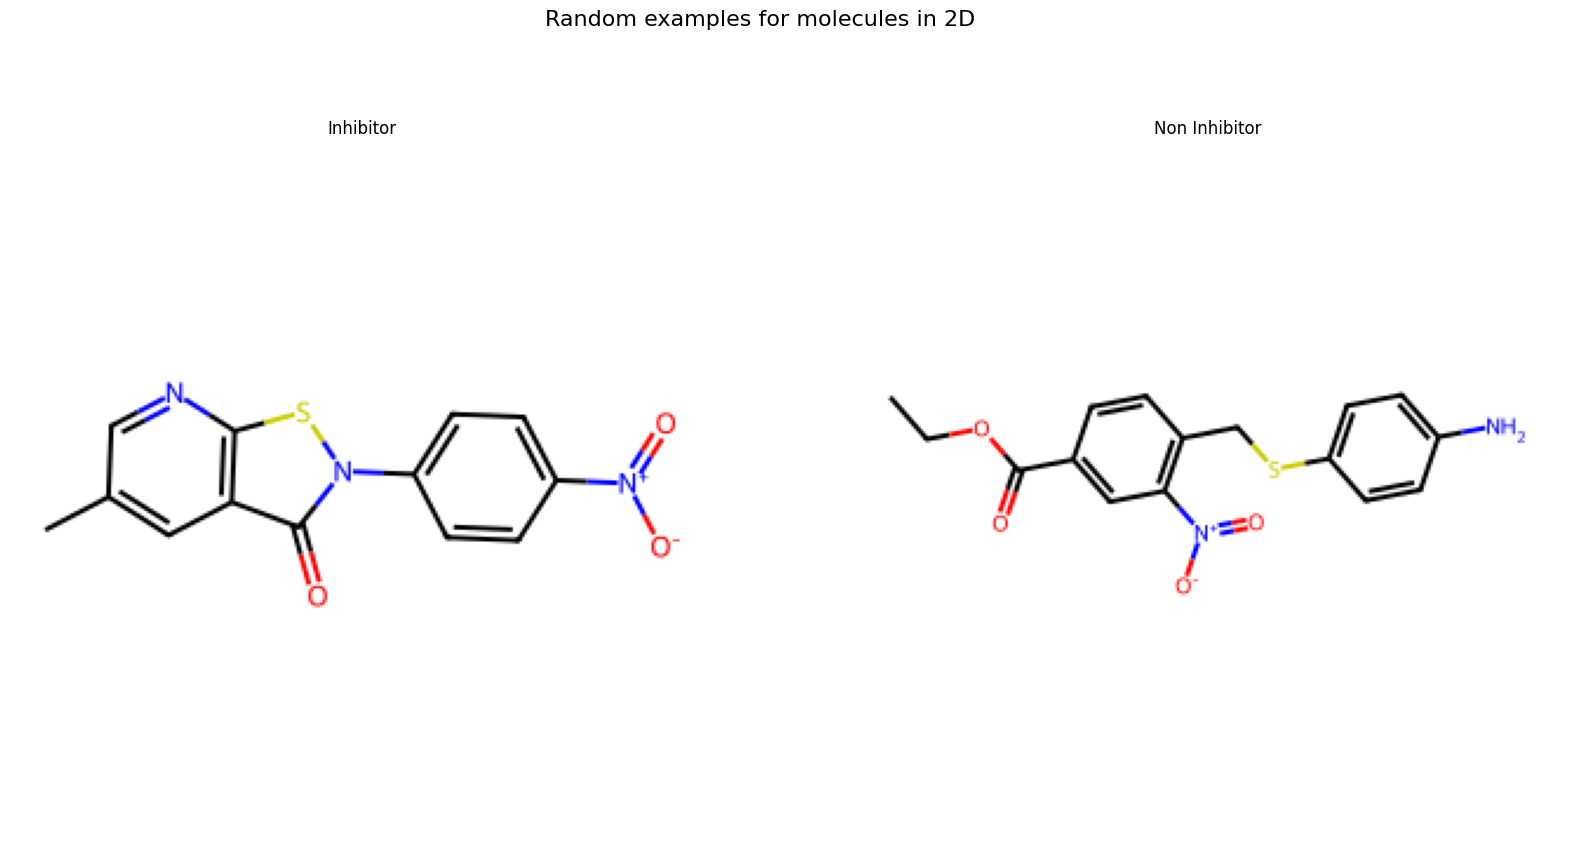

In [12]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1,2, figsize=(20,10))

axs[0].imshow(Draw.MolToImage(Chem.MolFromSmiles(example_pos.smiles)))
axs[0].axis('off')
axs[0].set_title('Inhibitor')

axs[1].imshow(Draw.MolToImage(Chem.MolFromSmiles(example_neg.smiles)))
axs[1].axis('off')
axs[1].set_title('Non Inhibitor')
fig.suptitle('Random examples for molecules in 2D', fontsize=16)
plt.show()

In [13]:
!pip install py3Dmol

In [14]:
from rdkit.Chem import AllChem
import py3Dmol

def read_mol_from_file(smile):
    mol = Chem.MolFromSmiles(smile)
    return mol

def generate_3D_coordinates(mol):
    AllChem.EmbedMolecule(mol, randomSeed=42, useRandomCoords=True)

def render_to_png(mol, filename):
    block = Chem.MolToMolBlock(mol)
    viewer = py3Dmol.view(width=300, height=300)
    viewer.addModel(block, "sdf")
    viewer.setStyle({'stick': {}})
    viewer.zoomTo()
    viewer.show()

In [15]:
mol = read_mol_from_file(example_pos.smiles)
generate_3D_coordinates(mol)
render_to_png(mol, 'example_pos.png')

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Dataset Imbalance

In [58]:
non_inhibitors = 0
inhibitors = 0

for d in dataset:
  if d.y == 0:
    non_inhibitors += 1
  else:
    inhibitors +=1

print('Dataset lenght is:', len(dataset))
print('The non inhibitors are', non_inhibitors, 'approximately', round(non_inhibitors/len(dataset) * 100, 2), '%')
print('The inhibitors are', inhibitors, 'approximately', round(inhibitors/len(dataset) * 100,2), '%')

Dataset lenght is: 41120
The non inhibitors are 39677 approximately 96.49 %
The inhibitors are 1443 approximately 3.51 %


#DATA AUGMENTATION
I wanted to perform data augmentation by using an Rdkit
https://www.knime.com/blog/4-techniques-handle-imbalanced-datasets

## Smiles Enumeration

I'll put into my __getitem__ method a smiles recombination, in order not to focus on the specific order of enumeration in the molecules but to look for the quantummechanical properties.

In this example I'll recalibrate the loss function simply.
I'll add a probability of smiles enumeration occurring.

In [59]:
import torch
from torch.utils.data import Dataset
import numpy as np
from torch_geometric.utils import from_smiles

class SmilesEnumDataset(Dataset):

    def __init__(self, data, prob = 0.5):
        self.probability = prob
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        # Pick an item and apply transf on the smiles to get a new data
        d = self.data.__getitem__(idx)

        if (random.random() < self.probability):
          mol = Chem.MolFromSmiles(d.smiles)
          smile_enum = Chem.MolToSmiles(mol, doRandom = True)
          smile_enum = from_smiles(smile_enum)
          smile_enum.y = d.y
          #print(smile_enum)
          return smile_enum

        else:
          return d

        sample = (torch.tensor(feature, dtype=torch.float32),
                  torch.tensor(label, dtype=torch.long)) # Assuming classification label

        return sample


In [60]:
from sklearn.model_selection import train_test_split
labels = [int(d.y.item()) for d in dataset]

# TRAIN, TEST, VAL split
train_data, temp_data, train_labels, temp_labels = train_test_split(dataset, labels, test_size=0.20, stratify=labels, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.50, stratify=temp_labels, random_state=42)

print(f"Dimensione Train: {len(train_data)}")
print(f"Dimensione Validation: {len(val_data)}")
print(f"Dimensione Test: {len(test_data)}")

train_data = SmilesEnumDataset(train_data, prob=0.6) #data augmentation

Dimensione Train: 32896
Dimensione Validation: 4112
Dimensione Test: 4112


https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

In [61]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

In [62]:
print(f"Numero di Batch nel Train: {len(train_loader)}")
next(iter(train_loader))

Numero di Batch nel Train: 514


DataBatch(x=[1535, 9], edge_index=[2, 3300], edge_attr=[3300, 3], smiles=[64], y=[64, 1], batch=[1535], ptr=[65])

In [63]:
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GCNConv, global_mean_pool

class SimpleGCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels):
        """
        Args:
            num_node_features: Il numero di feature in input per ogni atomo (x.shape[1]).
            hidden_channels: La grandezza della rete (es. 64 o 128 neuroni).
        """
        super().__init__()

        # --- 1. Strati di Message Passing ---
        # GCNConv prende le feature dei nodi (x) e la mappa dei legami (edge_index)
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)

        # --- 2. Strato di Classificazione Finale ---
        # Vogliamo un solo numero in uscita per la classificazione binaria
        self.lin = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):

        x = self.conv1(x, edge_index)
        x = x.relu()

        x = self.conv2(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)

        x = self.conv3(x, edge_index)

        # Prende le feature di tutti gli atomi e ne fa la media per ogni molecola nel batch
        x = global_mean_pool(x, batch)

        out = self.lin(x)


        return out

In [64]:
non_inhibitors/inhibitors

27.496188496188495

In [65]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sto addestrando su: {device}")

# 2. Inizializza il Modello
modello = SimpleGCN(9, 64)
modello = modello.to(device)

optimizer = torch.optim.Adam(modello.parameters(), lr=0.001)

peso_positivi = torch.tensor([27.0]).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=peso_positivi)

Sto addestrando su: cuda


In [66]:
from sklearn.metrics import roc_auc_score
num_epoche = 50 # Quante volte il modello vedrà l'intero dataset
# Creiamo i "diari" dove salvare i risultati
storia_train_loss = []
storia_val_loss = []
storia_val_auc = [] # Usiamo il ROC-AUC invece dell'Accuratezza!
for epoca in range(num_epoche):

    # ==========================================
    #             FASE DI TRAINING
    # ==========================================
    modello.train() # Diciamo al modello "Ora si studia!" (attiva il dropout)
    loss_train_totale = 0

    for batch in train_loader:
        # Sposta i dati sulla scheda video
        batch = batch.to(device)

        # dtypes check
        x_input = batch.x.float()
        edge_index_input = batch.edge_index.long()

        # 1. Azzera i calcoli dell'errore precedente
        optimizer.zero_grad()

        # 2. Forward Pass: Il modello prova a indovinare
        predizioni = modello(x_input, edge_index_input, batch.batch)

        # 3. Calcolo dell'Errore
        # Trucco salva-vita: squeeze() toglie le dimensioni extra [32, 1] -> [32]
        # float() assicura che le label siano compatibili con la loss
        loss = criterion(predizioni.squeeze(), batch.y.float().squeeze())

        # 4. Backward Pass: Calcola di quanto correggere i pesi
        loss.backward()

        # 5. Aggiornamento dei pesi
        optimizer.step()

        loss_train_totale += loss.item()

    loss_media_train = loss_train_totale / len(train_loader)

    # ==========================================
    #            FASE DI VALIDATION
    # ==========================================
    modello.eval() # Diciamo al modello "Ora sei all'esame!" (disattiva il dropout)
    loss_val_totale = 0
    corretti = 0
    totali = 0

    # Initialize lists to collect true labels and probabilities for ROC-AUC calculation
    y_true_epoch = []
    y_prob_epoch = []

    # torch.no_grad() spegne il motore dei gradienti: risparmia tantissima RAM!
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)

            # Explicitly ensure dtypes for GCNConv inputs
            x_input = batch.x.float()
            edge_index_input = batch.edge_index.long()

            # Il modello fa le sue previsioni sui dati mai visti
            predizioni = modello(x_input, edge_index_input, batch.batch)
            loss = criterion(predizioni.squeeze(), batch.y.float().squeeze())
            loss_val_totale += loss.item()

            # Calcoliamo l'accuratezza (solo per avere un'idea grezza)
            # Trasformiamo i numeri grezzi (logits) in probabilità (0-1) con la Sigmoid
            probabilita = torch.sigmoid(predizioni.squeeze())
            # Se la probabilità è > 0.5, diciamo che è Classe 1
            pred_labels = (probabilita > 0.5).float()

            corretti += (pred_labels == batch.y.float().squeeze()).sum().item()
            totali += len(batch.y)

            # Collect true labels and probabilities for ROC-AUC
            y_true_epoch.extend(batch.y.float().squeeze().cpu().numpy())
            y_prob_epoch.extend(probabilita.cpu().numpy())

    loss_media_val = loss_val_totale / len(val_loader)
    accuratezza_val = corretti / totali
  # Salviamo le loss medie dell'epoca corrente
    storia_train_loss.append(loss_media_train)
    storia_val_loss.append(loss_media_val)

    # Visto che siamo professionisti, calcoliamo il ROC-AUC ad ogni epoca sul Validation!
    try:
        # Use the collected true labels and probabilities
        auc_corrente = roc_auc_score(y_true_epoch, y_prob_epoch)
    except ValueError:
        auc_corrente = 0.5 # Nel caso rarissimo in cui in un batch ci sia solo una classe

    storia_val_auc.append(auc_corrente)

    if (epoca + 1) % 5 == 0 or epoca == 0:
        print(f'Epoca {epoca+1:03d} | Train Loss: {loss_media_train:.4f} | Val Loss: {loss_media_val:.4f} | Val AUC: {auc_corrente:.4f}')
    # ==========================================
    #             STAMPA RISULTATI
    # ==========================================
    # Stampiamo i risultati solo ogni 5 epoche per non inondare lo schermo
    if (epoca + 1) % 5 == 0 or epoca == 0:
        print(f'Epoca {epoca+1:03d} | Train Loss: {loss_media_train:.4f} | Val Loss: {loss_media_val:.4f} | Val Acc: {accuratezza_val:.4f}')

print("\nAddestramento Completato! 🎉")

Epoca 001 | Train Loss: 1.3298 | Val Loss: 1.3105 | Val AUC: 0.6383
Epoca 001 | Train Loss: 1.3298 | Val Loss: 1.3105 | Val Acc: 0.6391
Epoca 005 | Train Loss: 1.3006 | Val Loss: 1.3029 | Val AUC: 0.6507
Epoca 005 | Train Loss: 1.3006 | Val Loss: 1.3029 | Val Acc: 0.9497
Epoca 010 | Train Loss: 1.2743 | Val Loss: 1.2384 | Val AUC: 0.6836
Epoca 010 | Train Loss: 1.2743 | Val Loss: 1.2384 | Val Acc: 0.5800
Epoca 015 | Train Loss: 1.2276 | Val Loss: 1.1938 | Val AUC: 0.7045
Epoca 015 | Train Loss: 1.2276 | Val Loss: 1.1938 | Val Acc: 0.7648
Epoca 020 | Train Loss: 1.2002 | Val Loss: 1.1946 | Val AUC: 0.7070
Epoca 020 | Train Loss: 1.2002 | Val Loss: 1.1946 | Val Acc: 0.6294
Epoca 025 | Train Loss: 1.1718 | Val Loss: 1.1944 | Val AUC: 0.7079
Epoca 025 | Train Loss: 1.1718 | Val Loss: 1.1944 | Val Acc: 0.8701
Epoca 030 | Train Loss: 1.1624 | Val Loss: 1.1661 | Val AUC: 0.7233
Epoca 030 | Train Loss: 1.1624 | Val Loss: 1.1661 | Val Acc: 0.7354
Epoca 035 | Train Loss: 1.1693 | Val Loss: 1.168

In [77]:
torch.save(modello.state_dict(), "simple_gcn.pth")

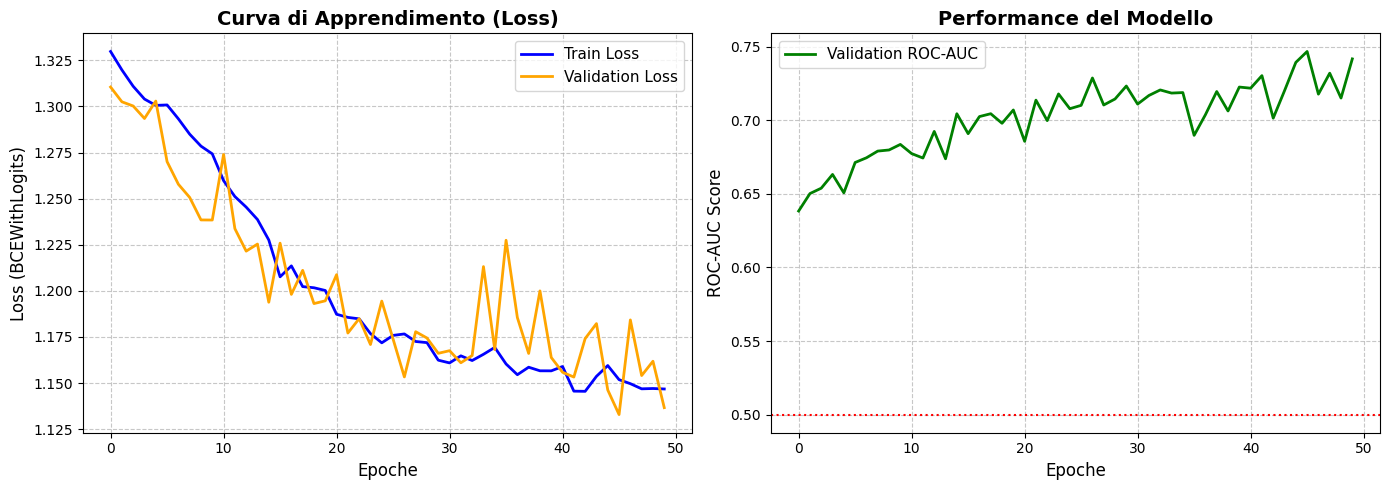

In [78]:
import matplotlib.pyplot as plt

# Creiamo una "tela" con 2 grafici affiancati (1 riga, 2 colonne)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# GRAFICO 1: LA CURVA DI LOSS (Errore)
# ==========================================
# Plottiamo la Loss del Train (blu) e del Validation (arancione)
ax1.plot(storia_train_loss, label='Train Loss', color='blue', linewidth=2)
ax1.plot(storia_val_loss, label='Validation Loss', color='orange', linewidth=2)

ax1.set_title('Curva di Apprendimento (Loss)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoche', fontsize=12)
ax1.set_ylabel('Loss (BCEWithLogits)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.7)

# ==========================================
# GRAFICO 2: LA CURVA DI PERFORMANCE (ROC-AUC)
# ==========================================
# Plottiamo come cresce il ROC-AUC nel tempo
ax2.plot(storia_val_auc, label='Validation ROC-AUC', color='green', linewidth=2)

ax2.set_title('Performance del Modello', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoche', fontsize=12)
ax2.set_ylabel('ROC-AUC Score', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.7)

# Linea di riferimento (0.5 = performance casuale, come lanciare una moneta)
ax2.axhline(y=0.5, color='red', linestyle=':', label='Casuale (0.5)')

# Mostriamo il capolavoro
plt.tight_layout()
plt.show()

In [79]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# ==========================================
# TEST FINALE SUL  TEST SET
# ==========================================
modello.eval()
tutte_le_vere_label = []
tutte_le_probabilita = []


with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        # Explicitly ensure dtypes for GCNConv inputs
        x_input = batch.x.float()
        edge_index_input = batch.edge_index.long()
        predizioni = modello(x_input, edge_index_input, batch.batch)

        # Estraiamo le probabilità (da 0.0 a 1.0)
        probabilita = torch.sigmoid(predizioni.squeeze())

        # Salviamo tutto in liste
        tutte_le_vere_label.extend(batch.y.cpu().numpy())
        tutte_le_probabilita.extend(probabilita.cpu().numpy())

# Convertiamo in array numpy per scikit-learn
y_true = np.array(tutte_le_vere_label)
y_prob = np.array(tutte_le_probabilita)

# Se la probabilità è > 0.5, la consideriamo Classe 1
y_pred = (y_prob > 0.5).astype(int)

print("=== MATRICE DI CONFUSIONE ===")
# Formato:
# [Veri Negativi (0)  Falsi Positivi (falsi allarmi)]
# [Falsi Negativi     Veri Positivi (HIV trovati!)]
print(confusion_matrix(y_true, y_pred))

print("\n=== REPORT DETTAGLIATO ===")
print(classification_report(y_true, y_pred, target_names=["Inattivo (0)", "Attivo (1)"]))

print("\n=== LA METRICA REALE ===")
roc_auc = roc_auc_score(y_true, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

AttributeError: 'dict' object has no attribute 'to'

## Undersampling

I want to try building many GNN. First I'll do a smiles enumeration and increment the inhibitor class. Then I'll build many classifiers by gnn and proceed by majority voting

In [32]:
dataset_0 = [d for d in dataset if d.y == 0]
dataset_1 = [d for d in dataset if d.y == 1]

# DATA LEAKAGE


In [33]:
import random

random.shuffle(dataset_0)
#DATA LEAKAGE

temp = []
print(dataset_0.__len__()/27) # 1469.51
dataset_0_splits = []
dataset_1_splits = []
for i in range(27):
  temp = dataset_0[i*1469:(i+1)*1469]
  random.shuffle(temp)
  dataset_0_splits.append(temp)
  dataset_1_splits.append(dataset_1)
  print(len(dataset_0_splits[0]))
  print(len(dataset_1_splits[0]))


1469.5185185185185
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443
1469
1443


In [35]:
# Costruisco i miei dataset
dataset_majority = {}

for i in range(27):
  labels = [int(d.y.item()) for d in dataset_0_splits[i]]

  train0_data, temp0_data, train0_labels, temp0_labels = train_test_split(dataset_0_splits[i], labels, test_size=0.20, random_state=42)
  val0_data, test0_data = train_test_split(temp0_data, test_size=0.50, random_state=42)


  # I'M GOING TO KEEP THE SAME DATA FOR LABEL 1: dataset_1_splits[0] is fine like that
  labels = [int(d.y.item()) for d in dataset_1_splits[0]]
  train1_data, temp1_data, train1_labels, temp1_labels = train_test_split(dataset_1_splits[0], labels, test_size=0.20, random_state=42)
  val1_data, test1_data = train_test_split(temp1_data, test_size=0.50, random_state=42)

  dataset_majority[f'lista{i}'] = {'train': train0_data + train1_data, 'test': test0_data + test1_data, 'val': val0_data+ val1_data}

len(dataset_majority['lista26']['train'])

2329

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sto addestrando su: {device}")

Sto addestrando su: cuda


In [37]:
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool

class MajorityGCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels):
        """
        Args:
            num_node_features: Il numero di feature in input per ogni atomo (x.shape[1]).
            hidden_channels: La grandezza della rete (es. 64 o 128 neuroni).
        """
        super().__init__()

        # --- 1. Strati di Message Passing ---
        # GCNConv prende le feature dei nodi (x) e la mappa dei legami (edge_index)
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

        # --- 2. Strato di Classificazione Finale ---
        # Vogliamo un solo numero in uscita per la classificazione binaria
        self.lin = Linear(2*hidden_channels, hidden_channels)
        self.lin2 = Linear(hidden_channels, 1)

    def forward(self, x, edge_index, batch):

        x = self.conv1(x, edge_index)
        x = x.relu()
        #x = F.dropout(x, p=0.3, training=self.training)

        x = self.conv2(x, edge_index)
        x = x.relu()

        # Prende le feature di tutti gli atomi e ne fa la media per ogni molecola nel batch
        x_1 = global_mean_pool(x, batch)
        x_2 = global_max_pool(x, batch)
        x = torch.cat((x_1, x_2), dim=1)

        x = self.lin(x)
        x = x.relu()
        out = self.lin2(x)

        return out

In [38]:
import torch

 #https://docs.pytorch.org/docs/2.12/generated/torch.nn.BCEWithLogitsLoss.html

In [39]:
import warnings
# Ignora i fastidiosi UserWarning generati da torch_geometric
warnings.filterwarnings("ignore", category=UserWarning, module="torch_geometric")

In [53]:
import torch
import json
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score

num_epoche = 20
tutte_le_storie = {}

for i in range(27):

    # ==========================================
    # AZZERO IL MODELLO
    # ==========================================
    modello = MajorityGCN(9, 64)
    modello = modello.to(device)
    optimizer = torch.optim.Adam(modello.parameters(), lr=0.001)
    criterion = torch.nn.BCEWithLogitsLoss()

    # ==========================================
    # COSTRUISCO I DATALOADER
    # ==========================================
    train_loader = DataLoader(dataset_majority[f'lista{i}']['train'], batch_size=64, shuffle=True)
    test_loader = DataLoader(dataset_majority[f'lista{i}']['test'], batch_size=64, shuffle=False)
    val_loader = DataLoader(dataset_majority[f'lista{i}']['val'], batch_size=64, shuffle=False)

    # ==========================================
    # DOVE SALVO I DATI LOCALI
    # ==========================================
    storia_train_loss = []
    storia_val_loss = []
    storia_val_auc = []

    # ==========================================
    # TRAINING (Ciclo Epoche)
    # ==========================================
    for epoca in range(num_epoche):

        modello.train()
        loss_train_totale = 0

        for batch in train_loader:
            batch = batch.to(device)

            # CONTROLLO FORMATTAZIONE
            x_input = batch.x.float()
            edge_index_input = batch.edge_index.long()

            # CLASSICO TRAINING
            optimizer.zero_grad()
            predizioni = modello(x_input, edge_index_input, batch.batch)
            loss = criterion(predizioni.squeeze(), batch.y.float().squeeze())

            loss.backward()  # CALCOLO GRADIENTE
            optimizer.step() # APPLICO SHIFT PESI

            loss_train_totale += loss.item()

        loss_media_train = loss_train_totale / len(train_loader)

        # ==========================================
        # VALIDATION
        # ==========================================
        modello.eval()
        loss_val_totale = 0
        corretti = 0
        totali = 0
        tutte_vere = []
        tutte_prob = []

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)

                # dtypes
                x_input = batch.x.float()
                edge_index_input = batch.edge_index.long()

                predizioni = modello(x_input, edge_index_input, batch.batch)
                loss = criterion(predizioni.squeeze(), batch.y.float().squeeze())
                loss_val_totale += loss.item()

                probabilita = torch.sigmoid(predizioni.squeeze())
                pred_labels = (probabilita > 0.5).float()

                corretti += (pred_labels == batch.y.float().squeeze()).sum().item()
                totali += len(batch.y)

                tutte_vere.extend(batch.y.float().squeeze().cpu().numpy())
                tutte_prob.extend(probabilita.cpu().numpy())

        loss_media_val = loss_val_totale / len(val_loader)
        accuratezza_val = corretti / totali

        storia_train_loss.append(loss_media_train)
        storia_val_loss.append(loss_media_val)

        try:
            auc_corrente = roc_auc_score(tutte_vere, tutte_prob)
        except ValueError:
            auc_corrente = 0.5

        storia_val_auc.append(auc_corrente)

        if (epoca + 1) % 5 == 0 or epoca == 0:
            print(f'Epoca {epoca+1:03d} | Train Loss: {loss_media_train:.4f} | Val Loss: {loss_media_val:.4f} | Val AUC: {auc_corrente:.4f} | Val Acc: {accuratezza_val:.4f}')

    # --- FINE DEL CICLO EPOCHE ---

    print(f"✅ Addestramento Modello {i} Completato!")

    # ==========================================
    # 💾 SALVATAGGIO DEI PESI DEL MODELLO
    # ==========================================
    # Questo ORA avviene SOLO ALLA FINE delle 10 epoche per il modello 'i'
    nome_file_modello = f"modello_pesi_lista_{i}.pth"
    torch.save(modello.state_dict(), nome_file_modello)
    print(f"💾 Pesi salvati in: {nome_file_modello}")

    # ==========================================
    # 📊 REGISTRAZIONE DELLE METRICHE
    # ==========================================
    # Questo ORA avviene SOLO ALLA FINE delle 10 epoche per il modello 'i'
    tutte_le_storie[f"lista{i}"] = {
        "train_loss": storia_train_loss,
        "val_loss": storia_val_loss,
        "val_auc": storia_val_auc
    }

# --- FINE DEL CICLO DEI 27 MODELLI ---

# ==========================================
# 💾 SALVATAGGIO FINALE DI TUTTE LE METRICHE
# ==========================================
# Questo avviene SOLO ALLA FINE di tutto il processo
with open("storia_tutti_i_modelli.json", "w") as f:
    json.dump(tutte_le_storie, f, indent=4)

print("\n🎉 TUTTO FATTO! 27 modelli addestrati e salvati con successo!")

Epoca 001 | Train Loss: 0.6925 | Val Loss: 0.6832 | Val AUC: 0.6375 | Val Acc: 0.5636
Epoca 005 | Train Loss: 0.6559 | Val Loss: 0.6532 | Val AUC: 0.6406 | Val Acc: 0.5979
Epoca 010 | Train Loss: 0.6439 | Val Loss: 0.6469 | Val AUC: 0.6588 | Val Acc: 0.6254
Epoca 015 | Train Loss: 0.6327 | Val Loss: 0.6412 | Val AUC: 0.6637 | Val Acc: 0.6254
Epoca 020 | Train Loss: 0.6357 | Val Loss: 0.6374 | Val AUC: 0.6687 | Val Acc: 0.6186
✅ Addestramento Modello 0 Completato!
💾 Pesi salvati in: modello_pesi_lista_0.pth
Epoca 001 | Train Loss: 0.6942 | Val Loss: 0.6897 | Val AUC: 0.6658 | Val Acc: 0.6392
Epoca 005 | Train Loss: 0.6714 | Val Loss: 0.6640 | Val AUC: 0.6823 | Val Acc: 0.6289
Epoca 010 | Train Loss: 0.6482 | Val Loss: 0.6414 | Val AUC: 0.6778 | Val Acc: 0.6357
Epoca 015 | Train Loss: 0.6399 | Val Loss: 0.6363 | Val AUC: 0.6695 | Val Acc: 0.5876
Epoca 020 | Train Loss: 0.6321 | Val Loss: 0.6540 | Val AUC: 0.6653 | Val Acc: 0.6117
✅ Addestramento Modello 1 Completato!
💾 Pesi salvati in: m

# Majority Voting (Ensemble dei 27 modelli)

1. Ricostruisco lo **stesso** test set tenuto da parte in fase di training (blocchi classe 0 disgiunti + classe 1 condivisa).
2. Ricarico i 27 `MajorityGCN` dai file `modello_pesi_lista_{i}.pth`.
3. Ogni modello produce una probabilita per ogni molecola.
4. Aggrego con **hard voting** (voto di maggioranza, >=14/27) e **soft voting** (media delle probabilita).

In [54]:
# ==========================================
# 1. RICOSTRUISCO IL TEST SET COMUNE
# ==========================================
# Uso gli STESSI split (random_state=42) usati in fase di training,
# cosi le molecole di test sono identiche a quelle tenute da parte.
from sklearn.model_selection import train_test_split

NUM_MODELLI = 27

test_classe0 = []
for i in range(NUM_MODELLI):
    lab = [0] * len(dataset_0_splits[i])
    _, temp0, _, _ = train_test_split(dataset_0_splits[i], lab,
                                       test_size=0.20, random_state=42)
    _, test0 = train_test_split(temp0, test_size=0.50, random_state=42)
    test_classe0 += test0   # blocchi disgiunti -> nessun doppione

# Classe 1: stesso split per tutti i modelli, la prendo UNA volta sola
lab1 = [1] * len(dataset_1_splits[0])
_, temp1, _, _ = train_test_split(dataset_1_splits[0], lab1,
                                  test_size=0.20, random_state=42)
_, test1 = train_test_split(temp1, test_size=0.50, random_state=42)

test_comune = test_classe0 + test1
print(f"Test set comune: {len(test_comune)} molecole "
      f"({len(test_classe0)} inattive + {len(test1)} attive)")


Test set comune: 4114 molecole (3969 inattive + 145 attive)


In [ ]:
# ==========================================
# 2. RICARICO I 27 MODELLI ADDESTRATI
# ==========================================
modelli = []
for i in range(NUM_MODELLI):
    m = MajorityGCN(9, 64).to(device)
    m.load_state_dict(torch.load(f"modello_pesi_lista_{i}.pth", map_location=device))
    m.eval()
    modelli.append(m)

print(f"Caricati {len(modelli)} modelli.")


Caricati 27 modelli.


In [ ]:
# ==========================================
# 3. RACCOLGO LE PROBABILITA DI OGNI MODELLO
# ==========================================
# Scorro il test set UNA volta (shuffle=False) e per ogni batch
# faccio predire tutti i 27 modelli: cosi le molecole restano allineate.
import numpy as np
from torch_geometric.loader import DataLoader

test_loader = DataLoader(test_comune, batch_size=64, shuffle=False)

y_true = []
prob_per_modello = [[] for _ in range(NUM_MODELLI)]

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        x_input = batch.x.float()
        edge_index_input = batch.edge_index.long()

        y_true.extend(batch.y.float().view(-1).cpu().numpy())

        for j, m in enumerate(modelli):
            out = m(x_input, edge_index_input, batch.batch)
            prob = torch.sigmoid(out.view(-1))          # view(-1) e' robusto anche con batch da 1
            prob_per_modello[j].extend(prob.cpu().numpy())

y_true = np.array(y_true)
prob_matrix = np.array(prob_per_modello)   # forma: [27, N_molecole]
print("Matrice probabilita:", prob_matrix.shape)


Matrice probabilita: (27, 4114)


In [ ]:
# ==========================================
# 4. MAJORITY VOTING + METRICHE
# ==========================================
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# --- HARD VOTING: ogni modello vota 0/1, vince la maggioranza ---
voti = (prob_matrix > 0.5).astype(int)          # [27, N]
somma_voti = voti.sum(axis=0)                    # quanti modelli dicono "attivo"
y_pred_hard = (somma_voti >= (14)).astype(int)   # >=14/27

# --- SOFT VOTING: media delle probabilita (di solito piu' stabile) ---
prob_media = prob_matrix.mean(axis=0)            # [N]
y_pred_soft = (prob_media > 0.5).astype(int)

print("================ HARD VOTING (>=14/27) ================")
print(confusion_matrix(y_true, y_pred_hard))
print(classification_report(y_true, y_pred_hard,
      target_names=["Inattivo (0)", "Attivo (1)"]))

print("================ SOFT VOTING (media prob) =============")
print(confusion_matrix(y_true, y_pred_soft))
print(classification_report(y_true, y_pred_soft,
      target_names=["Inattivo (0)", "Attivo (1)"]))

# ROC-AUC: si usano le probabilita (la media e' la scelta naturale per l'ensemble)
auc_soft = roc_auc_score(y_true, prob_media)
auc_hard = roc_auc_score(y_true, somma_voti / NUM_MODELLI)  # frazione di voti come "score"
print(f"\nROC-AUC (soft, prob media): {auc_soft:.4f}")
print(f"ROC-AUC (hard, frazione voti): {auc_hard:.4f}")


================ HARD VOTING (>=14/27) ================
[[1921 2048]
 [  40  105]]
              precision    recall  f1-score   support

Inattivo (0)       0.98      0.48      0.65      3969
  Attivo (1)       0.05      0.72      0.09       145

    accuracy                           0.49      4114
   macro avg       0.51      0.60      0.37      4114
weighted avg       0.95      0.49      0.63      4114

================ SOFT VOTING (media prob) =============
[[2569 1400]
 [  60   85]]
              precision    recall  f1-score   support

Inattivo (0)       0.98      0.65      0.78      3969
  Attivo (1)       0.06      0.59      0.10       145

    accuracy                           0.65      4114
   macro avg       0.52      0.62      0.44      4114
weighted avg       0.94      0.65      0.75      4114


ROC-AUC (soft, prob media): 0.6712
ROC-AUC (hard, frazione voti): 0.6727


#Transfer Learning

Freezing a huge net


In [69]:
%%capture
!pip install transformers

In [80]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel

# ChemBERTa pre-addestrato su SMILES (PubChem). Si puo' sostituire con altri,
# es. "seyonec/ChemBERTa-zinc-base-v1".
MODEL_NAME = "DeepChem/ChemBERTa-77M-MLM"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ChemBERTaClassifier(nn.Module):
    def __init__(self, model_name=MODEL_NAME, freeze_backbone=True):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.backbone.config.hidden_size

        # Congelo il backbone: alleno solo la testa (veloce e stabile).
        # Metti freeze_backbone=False per il fine-tuning completo.
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1)          # 1 logit per classificazione binaria
        )

    def forward(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]   # rappresentazione del token [CLS]
        return self.head(cls)

print("Tokenizer e modello pronti.")

Tokenizer e modello pronti.


In [81]:
from torch.utils.data import Dataset, DataLoader as TorchDataLoader

class SmilesDataset(Dataset):
    """Tokenizza gli SMILES al volo per ChemBERTa."""
    def __init__(self, smiles_list, labels, tokenizer, max_len=128):
        self.smiles = smiles_list
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.smiles[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.float32),
        }

In [82]:
from sklearn.model_selection import train_test_split

# Estraggo SMILES + label dal dataset MoleculeNet (NON tocco la variabile dataset).
smiles_all = [d.smiles for d in dataset]
y_all = [int(d.y.item()) for d in dataset]

# Split stratificato 80 / 10 / 10
sm_train, sm_temp, y_train, y_temp = train_test_split(
    smiles_all, y_all, test_size=0.20, stratify=y_all, random_state=42)
sm_val, sm_test, y_val, y_test = train_test_split(
    sm_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

train_ds = SmilesDataset(sm_train, y_train, tokenizer)
val_ds   = SmilesDataset(sm_val,   y_val,   tokenizer)
test_ds  = SmilesDataset(sm_test,  y_test,  tokenizer)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 32896 | Val: 4112 | Test: 4112


In [83]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sto addestrando su: {device}")

BATCH_SIZE = 64
train_loader = TorchDataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = TorchDataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = TorchDataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

modello_bert = ChemBERTaClassifier(freeze_backbone=True).to(device)

# Alleno solo i parametri NON congelati (la testa)
parametri = filter(lambda p: p.requires_grad, modello_bert.parameters())
optimizer = optim.Adam(parametri, lr=1e-3)

# Loss pesata per lo sbilanciamento (n_negativi / n_positivi sul train)
n_pos = sum(y_train)
n_neg = len(y_train) - n_pos
peso_positivi = torch.tensor([n_neg / n_pos]).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=peso_positivi)
print(f"pos_weight = {peso_positivi.item():.2f}")

Sto addestrando su: cuda


Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MLM
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.decoder.bias      | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


pos_weight = 27.51


In [84]:
import numpy as np
from sklearn.metrics import roc_auc_score

num_epoche = 20

for epoca in range(num_epoche):
    # ---------------- TRAINING ----------------
    modello_bert.train()
    loss_totale = 0
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        y_true = batch["label"].to(device)

        optimizer.zero_grad()
        logits = modello_bert(input_ids, attention_mask).squeeze(-1)
        loss = criterion(logits, y_true)
        loss.backward()
        optimizer.step()
        loss_totale += loss.item()
    loss_media = loss_totale / len(train_loader)

    # ---------------- VALIDATION ----------------
    modello_bert.eval()
    tutte_vere, tutte_prob = [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = modello_bert(input_ids, attention_mask).squeeze(-1)
            prob = torch.sigmoid(logits)
            tutte_vere.extend(batch["label"].numpy())
            tutte_prob.extend(prob.cpu().numpy())

    try:
        auc_val = roc_auc_score(tutte_vere, tutte_prob)
    except ValueError:
        auc_val = 0.5

    print(f"Epoca {epoca+1:02d} | Train Loss: {loss_media:.4f} | Val ROC-AUC: {auc_val:.4f}")

print("Fine training ChemBERTa!")

Epoca 01 | Train Loss: 1.2484 | Val ROC-AUC: 0.6843
Epoca 02 | Train Loss: 1.1840 | Val ROC-AUC: 0.7122
Epoca 03 | Train Loss: 1.1534 | Val ROC-AUC: 0.7293
Epoca 04 | Train Loss: 1.1287 | Val ROC-AUC: 0.7225
Epoca 05 | Train Loss: 1.1144 | Val ROC-AUC: 0.7309
Epoca 06 | Train Loss: 1.0975 | Val ROC-AUC: 0.7244
Epoca 07 | Train Loss: 1.0852 | Val ROC-AUC: 0.7370
Epoca 08 | Train Loss: 1.0566 | Val ROC-AUC: 0.7344
Epoca 09 | Train Loss: 1.0599 | Val ROC-AUC: 0.7530
Epoca 10 | Train Loss: 1.0616 | Val ROC-AUC: 0.7468
Epoca 11 | Train Loss: 1.0322 | Val ROC-AUC: 0.7355
Epoca 12 | Train Loss: 1.0297 | Val ROC-AUC: 0.7450
Epoca 13 | Train Loss: 1.0076 | Val ROC-AUC: 0.7460
Epoca 14 | Train Loss: 1.0163 | Val ROC-AUC: 0.7373
Epoca 15 | Train Loss: 1.0055 | Val ROC-AUC: 0.7498
Epoca 16 | Train Loss: 0.9951 | Val ROC-AUC: 0.7550
Epoca 17 | Train Loss: 0.9966 | Val ROC-AUC: 0.7644
Epoca 18 | Train Loss: 0.9761 | Val ROC-AUC: 0.7521
Epoca 19 | Train Loss: 0.9650 | Val ROC-AUC: 0.7477
Epoca 20 | T

In [85]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# ---------------- TEST FINALE ----------------
modello_bert.eval()
y_vere, y_prob = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits = modello_bert(input_ids, attention_mask).squeeze(-1)
        prob = torch.sigmoid(logits)
        y_vere.extend(batch["label"].numpy())
        y_prob.extend(prob.cpu().numpy())

y_vere = np.array(y_vere)
y_prob = np.array(y_prob)
y_pred = (y_prob > 0.5).astype(int)

print("=== MATRICE DI CONFUSIONE ===")
print(confusion_matrix(y_vere, y_pred))
print("\n=== REPORT DETTAGLIATO ===")
print(classification_report(y_vere, y_pred, target_names=["Inattivo (0)", "Attivo (1)"]))
print(f"\nROC-AUC Score: {roc_auc_score(y_vere, y_prob):.4f}")

=== MATRICE DI CONFUSIONE ===
[[3243  725]
 [  68   76]]

=== REPORT DETTAGLIATO ===
              precision    recall  f1-score   support

Inattivo (0)       0.98      0.82      0.89      3968
  Attivo (1)       0.09      0.53      0.16       144

    accuracy                           0.81      4112
   macro avg       0.54      0.67      0.53      4112
weighted avg       0.95      0.81      0.87      4112


ROC-AUC Score: 0.7448


In [87]:
torch.save(modello_bert.state_dict(), "chemberta.pth")